In [7]:
# ======================= ColO-RAN quick visualizer ===========================
import os, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

UE files: 6 → showing first one


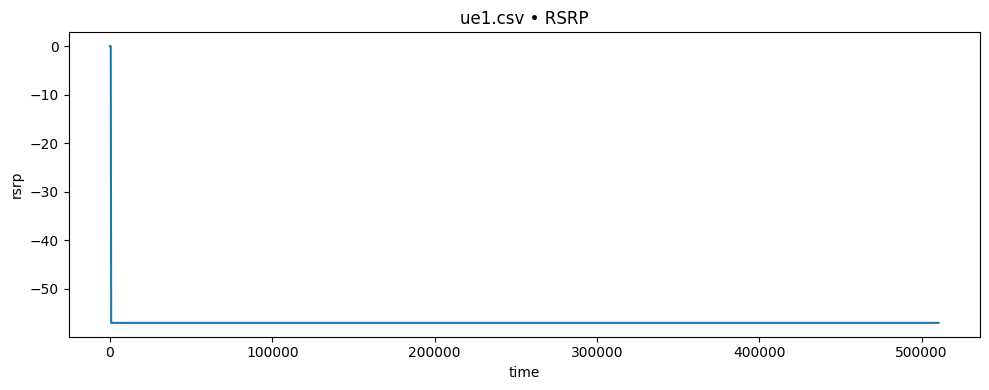

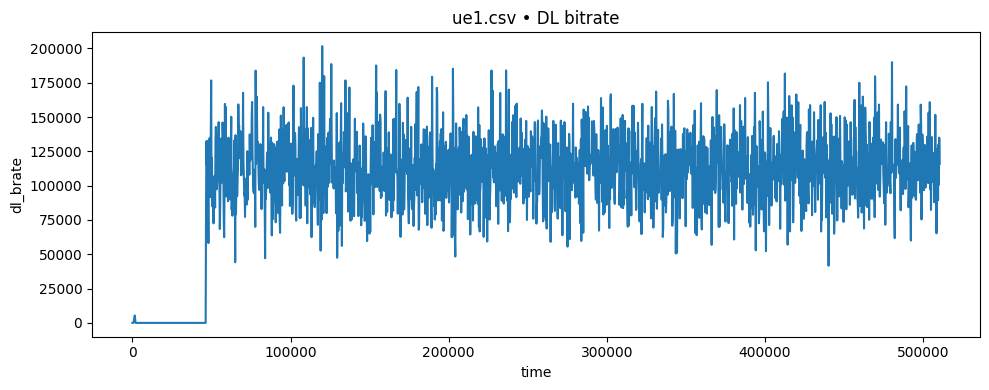

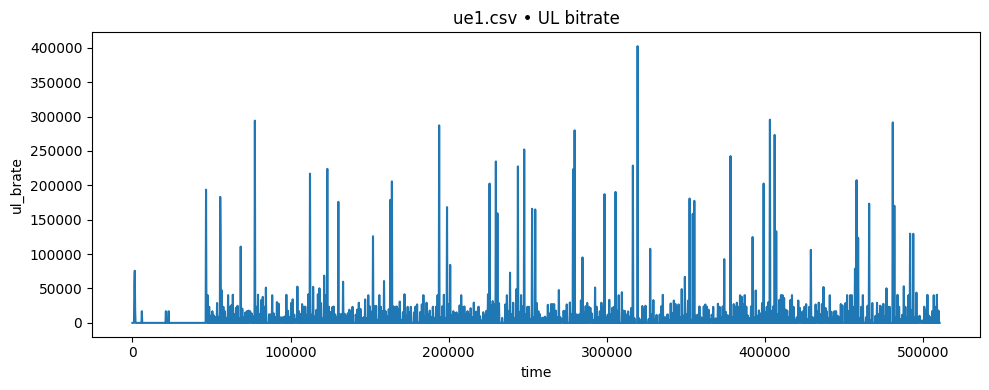

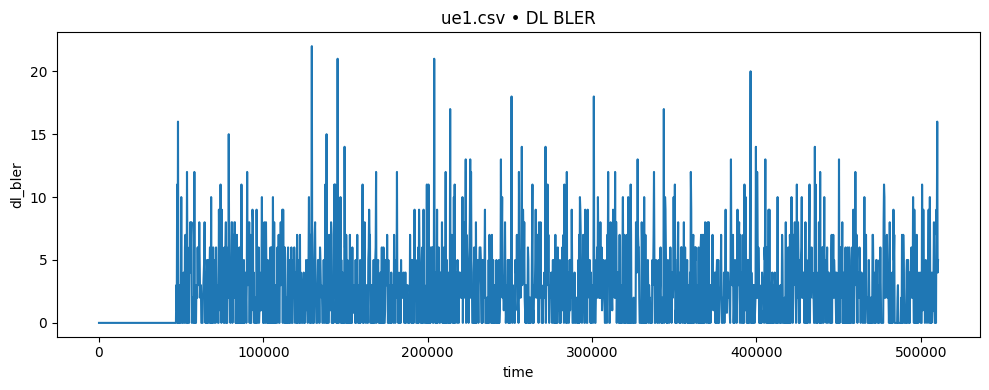

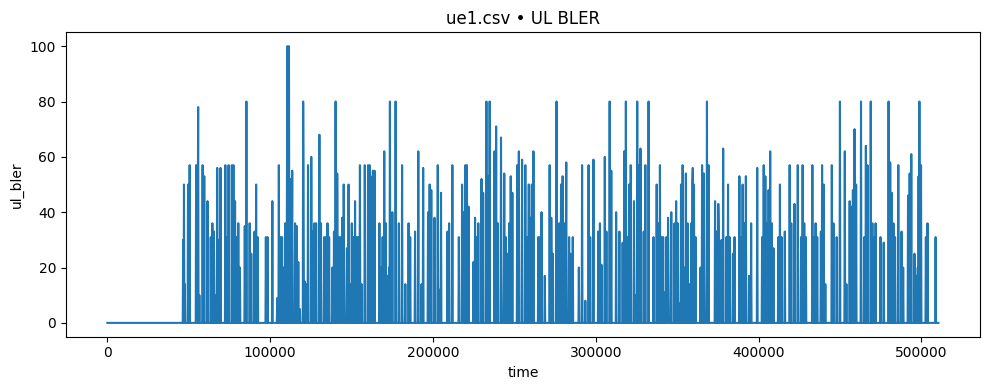

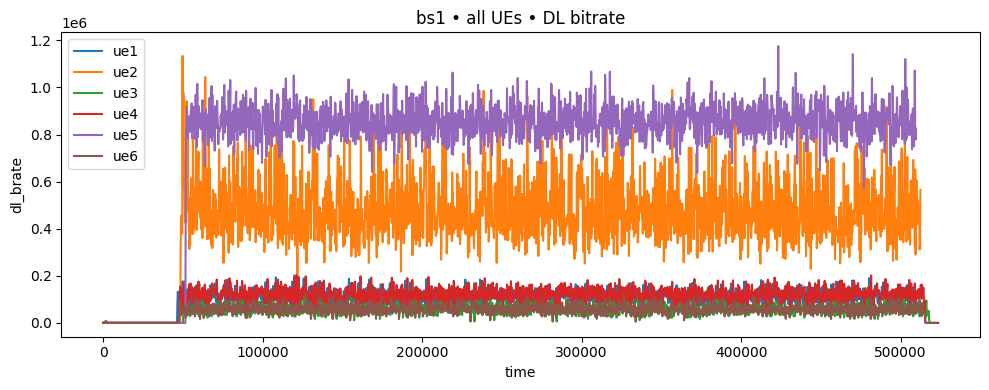

Slice files: 6 → showing first one


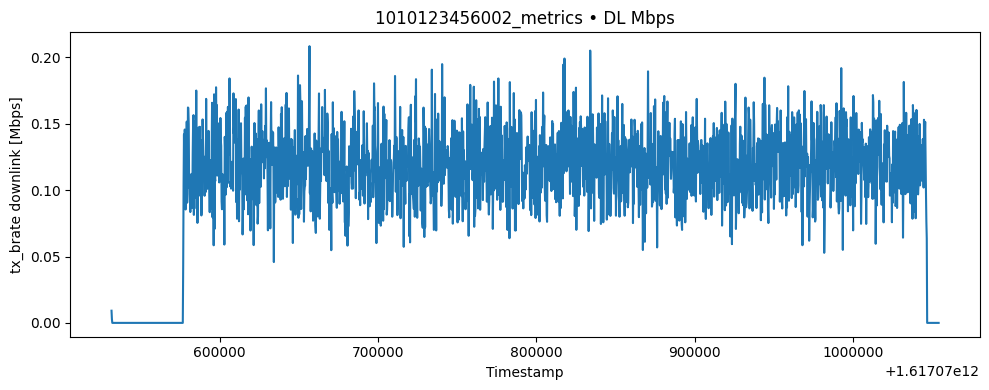

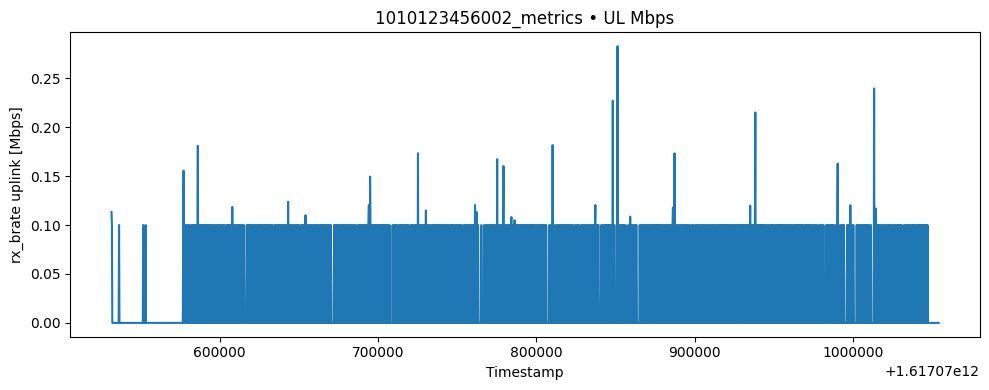

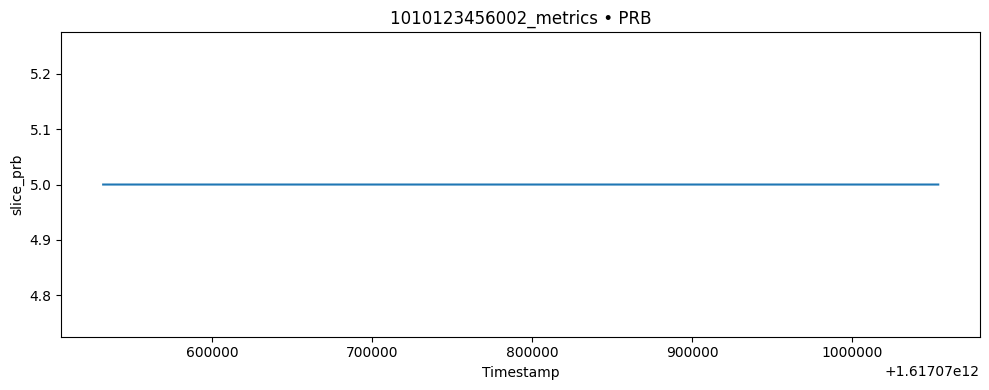

BS files: 1 → showing first one


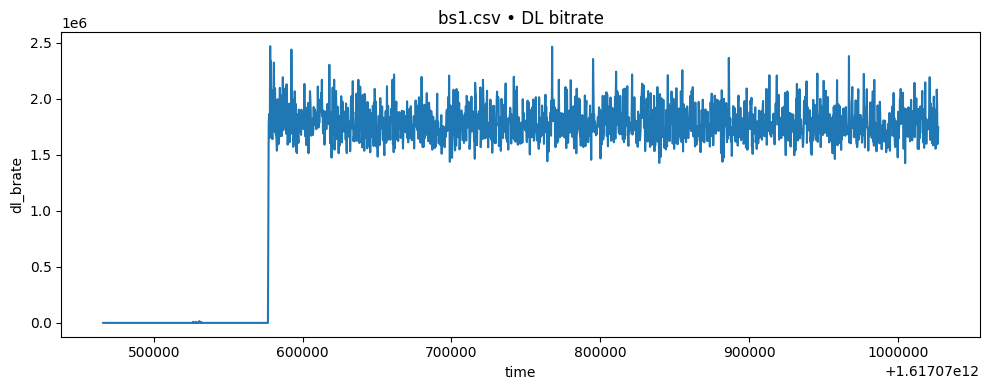

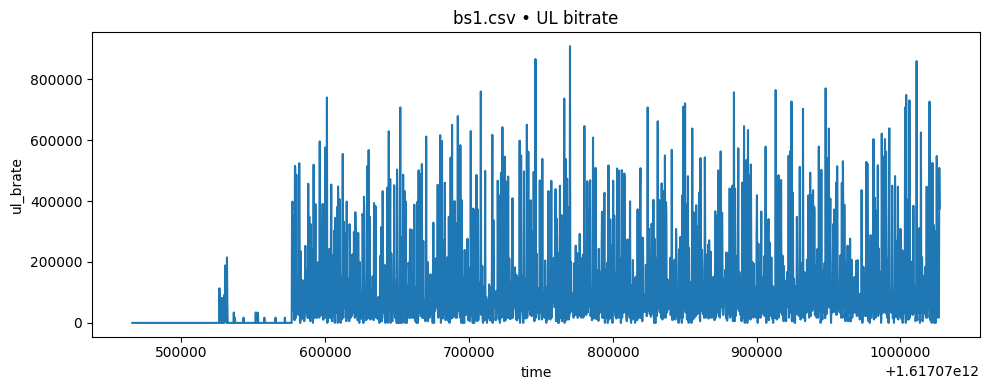

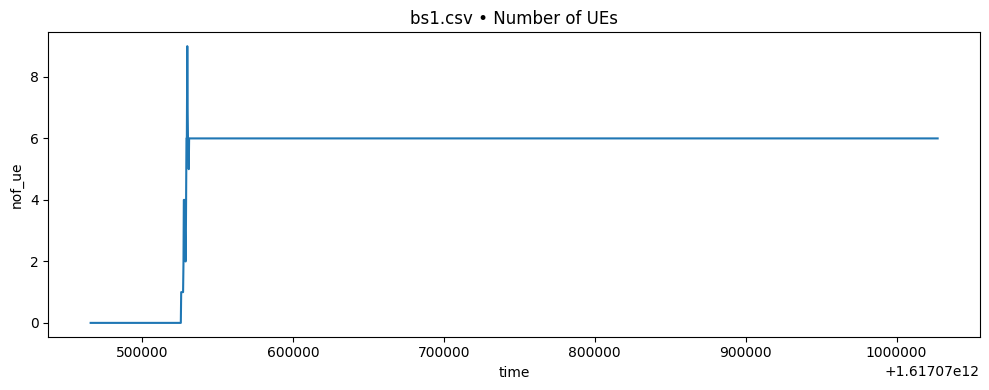

In [ ]:
# ---- CONFIG ----
BASE_SCHED_DIR = Path(r"../data/sched0")  # change to sched1/sched2 if needed
TR, EXP, BS = "tr0", "exp1", "bs1"     # pick a scenario to start

# ---- helpers ----------------------------------------------------------------
def list_csvs(base: Path, entity: str, tr=None, exp=None, bs=None):
    root = base
    if tr:  root = root / tr
    if exp: root = root / exp
    if bs:  root = root / bs
    if not root.exists(): return []
    out = []
    for r,_,files in os.walk(root):
        for f in files:
            if not f.lower().endswith(".csv"): continue
            p = Path(r)/f
            if entity=="ue"   and re.fullmatch(r"ue\d+\.csv", p.name, flags=re.I): out.append(p)
            if entity=="bs"   and re.fullmatch(r"bs\d+\.csv", p.name, flags=re.I): out.append(p)
            if entity=="slice" and any(seg.lower().startswith("slices_bs") for seg in p.parts): out.append(p)
    return sorted(out)

def choose_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    # soft match by lowercase includes (for odd labels)
    lc = {c.lower(): c for c in df.columns}
    for patt in candidates:
        patt_l = patt.lower()
        for k,v in lc.items():
            if patt_l in k: return v
    return None

def read_df(path):
    df = pd.read_csv(path)
    # drop unnamed junk
    for c in list(df.columns):
        if str(c).lower().startswith("unnamed"):
            df = df.drop(columns=[c])
    return df

# ---- plotting primitives (one chart per plot per the rules) -----------------
def plot_series(df, x, y, title):
    if x not in df.columns or y not in df.columns:
        print(f"Skip: missing {x} or {y}")
        return
    plt.figure(figsize=(10,4))
    plt.plot(df[x], df[y])
    plt.xlabel(x); plt.ylabel(y); plt.title(title)
    plt.tight_layout(); plt.show()

def overlay_many(dfs, x, y, labels, title):
    plt.figure(figsize=(10,4))
    for df,lab in zip(dfs, labels):
        if x in df.columns and y in df.columns:
            plt.plot(df[x], df[y], label=lab)
    plt.xlabel(x); plt.ylabel(y); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

# ============================ UE VISUALS =====================================
ue_files = list_csvs(BASE_SCHED_DIR, "ue", TR, EXP, BS)
print(f"UE files: {len(ue_files)} → showing first one")

if ue_files:
    df_ue = read_df(ue_files[0])

    time_col = choose_col(df_ue, ["time","Timestamp","timestamp"])
    # from your labels:
    rsrp  = choose_col(df_ue, ["rsrp"])
    dlbr  = choose_col(df_ue, ["dl_brate","tx_brate downlink [Mbps]"])
    ulbr  = choose_col(df_ue, ["ul_brate","rx_brate uplink [Mbps]"])
    dlbl  = choose_col(df_ue, ["dl_bler"])
    ulbl  = choose_col(df_ue, ["ul_bler"])

    plot_series(df_ue, time_col, rsrp,  f"{ue_files[0].name} • RSRP")
    if dlbr: plot_series(df_ue, time_col, dlbr,  f"{ue_files[0].name} • DL bitrate")
    if ulbr: plot_series(df_ue, time_col, ulbr,  f"{ue_files[0].name} • UL bitrate")
    if dlbl: plot_series(df_ue, time_col, dlbl,  f"{ue_files[0].name} • DL BLER")
    if ulbl: plot_series(df_ue, time_col, ulbl,  f"{ue_files[0].name} • UL BLER")

# Overlay all UEs in the same BS by DL bitrate
if ue_files:
    ue_dfs = [read_df(p) for p in ue_files]
    time_col = choose_col(ue_dfs[0], ["time","Timestamp","timestamp"])
    dlbr = choose_col(ue_dfs[0], ["dl_brate","tx_brate downlink [Mbps]"])
    if time_col and dlbr:
        overlay_many(ue_dfs, time_col, dlbr, [p.stem for p in ue_files],
                     f"{BS} • all UEs • DL bitrate")

# =========================== SLICE VISUALS ===================================
slice_files = list_csvs(BASE_SCHED_DIR, "slice", TR, EXP, BS)
print(f"Slice files: {len(slice_files)} → showing first one")

if slice_files:
    df_sl = read_df(slice_files[0])
    # from your labels:
    time_col = choose_col(df_sl, ["Timestamp","time","timestamp"])
    dl_mbps = choose_col(df_sl, ["tx_brate downlink [Mbps]","dl_brate"])
    ul_mbps = choose_col(df_sl, ["rx_brate uplink [Mbps]","ul_brate"])
    prb     = choose_col(df_sl, ["slice_prb","sum_granted_prbs"])

    if dl_mbps: plot_series(df_sl, time_col, dl_mbps, f"{slice_files[0].stem} • DL Mbps")
    if ul_mbps: plot_series(df_sl, time_col, ul_mbps, f"{slice_files[0].stem} • UL Mbps")
    if prb:     plot_series(df_sl, time_col, prb,     f"{slice_files[0].stem} • PRB")

# ============================= BS VISUALS ====================================
bs_files = list_csvs(BASE_SCHED_DIR, "bs", TR, EXP, BS)
print(f"BS files: {len(bs_files)} → showing first one")

if bs_files:
    df_bs = read_df(bs_files[0])
    time_col = choose_col(df_bs, ["time","Timestamp","timestamp"])
    dlbr = choose_col(df_bs, ["dl_brate","tx_brate downlink [Mbps]"])
    ulbr = choose_col(df_bs, ["ul_brate","rx_brate uplink [Mbps]"])
    nof  = choose_col(df_bs, ["nof_ue","num_ue","ues"])

    if dlbr: plot_series(df_bs, time_col, dlbr, f"{bs_files[0].name} • DL bitrate")
    if ulbr: plot_series(df_bs, time_col, ulbr, f"{bs_files[0].name} • UL bitrate")
    if nof:  plot_series(df_bs, time_col, nof,  f"{bs_files[0].name} • Number of UEs")

Entries:

RSRP: Reference Signal Received Power

DL: Down Link Bit rate 

UL: Up Link Bit rate

DL BLER: Down Link Block Error Rate

UL BLER: Up Link Block Error Rate

DL MBPS: Download Megabits Per Second

UL MBPS: Upload Megabits Per Second

PRB: Physical Resource Blocks